In [1]:
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import plotly.express as px
from sentence_transformers import SentenceTransformer
import umap

from sklearn.decomposition import PCA

In [2]:
# 1. 取得 XKCD 顏色數據
xkcd_colors = {name.replace('xkcd:', ''): hex_val for name, hex_val in mcolors.XKCD_COLORS.items()}
names = list(xkcd_colors.keys())
name_to_idx = {name: i for i, name in enumerate(names)}
hex_codes = list(xkcd_colors.values())

# 2. 產生成 Embedding (LLM 輸出)
model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(names, show_progress_bar=True)

dim = len(embeddings[0])

Batches:   0%|          | 0/30 [00:00<?, ?it/s]

In [3]:
# 3. 使用 UMAP 降維至三維
# n_neighbors: 較大的值會保留更多全局結構，較小則保留局部細節
linear = False # <-------------------------------------------------------

if not linear:
    reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42)
    embeddings_3d = reducer.fit_transform(embeddings)
else:
    # alter, linear
    pca_reducer = PCA(n_components=3, random_state=42)
    embeddings_3d = pca_reducer.fit_transform(embeddings)
    exp_var_ratio = pca_reducer.explained_variance_ratio_
    cum_var_ratio = np.cumsum(exp_var_ratio)
    print("=== PCA 變異數分析 ===")
    accu = 0.0
    for i, ratio in enumerate(exp_var_ratio):
        accu += ratio
        print(f"主成分 PC{i+1}: {ratio:.2%} (單獨解釋度), {accu:.2%} (累積解釋度)")

# 4. 整理成 DataFrame 並儲存
df = pd.DataFrame(embeddings_3d, columns=['x', 'y', 'z'])
df['color'] = names
df['hex'] = hex_codes
#df.to_csv('xkcd_colors_3d.csv', index=False)

/opt/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [4]:
# 5. 使用 Plotly 繪製交互式 3D 圖表
fig = px.scatter_3d(
    df, 
    x='x', y='y', z='z',
    color='hex',                # 指定顏色依據 hex 欄位
    color_discrete_map="identity", # 重要：這行告訴 Plotly 直接使用 hex 字串作為顏色
    hover_name='color',    # 懸停時顯示顏色名稱
    hover_data={'hex': True, 'x': False, 'y': False, 'z': False},
    title='XKCD Color Name Semantic Space (UMAP 3D)',
    labels={'x': 'UMAP 1', 'y': 'UMAP 2', 'z': 'UMAP 3'}
)

# 優化視覺效果
fig.update_traces(marker=dict(size=4, opacity=0.8, line=dict(width=0.5, color='gray')))
fig.update_layout(
    autosize=False,
    width=800,
    height=800,
    scene=dict(
        # 固定座標軸比例為 1:1:1，確保視覺上是正立方體
        aspectmode='cube', 
        xaxis=dict(title='UMAP 1'),
        yaxis=dict(title='UMAP 2'),
        zaxis=dict(title='UMAP 3'),
        xaxis_backgroundcolor="rgba(200, 200, 200, 0.1)",
        yaxis_backgroundcolor="rgba(200, 200, 200, 0.1)",
        zaxis_backgroundcolor="rgba(200, 200, 200, 0.1)"
    ),
    margin=dict(l=0, r=0, b=0, t=50), # 減少邊距讓圖表更大
    title_x=0.5 # 標題置中
)

# 顯示圖表
fig.show()

In [5]:
primary_and_base_colors = [
    # 基礎無彩色 (Achromatic colors)
    "black", 
    "white", 
    "grey", 
    
    # 光學三原色 (RGB) 與 繪畫三原色 (RYB) 的交集
    "red", 
    "green", 
    "blue", 
    "yellow",
    
    # 印刷三原色 (CMY) 的剩餘部分
    "cyan", 
    "magenta"
]

In [6]:
primary_embeddings = []
primary_embeddings_3d = []
for color in primary_and_base_colors:
    if color in name_to_idx:
        idx = name_to_idx[color]
        primary_embeddings.append(embeddings[idx])
        primary_embeddings_3d.append(embeddings_3d[idx]) # umap 3D
    else:
        print(f"警告: 找不到顏色 '{color}'")

In [7]:
pd.DataFrame([primary_and_base_colors, primary_embeddings, primary_embeddings_3d])

,0,1,2,3,4,5,6,7,8
0,black,white,grey,red,green,blue,yellow,cyan,magenta
1,"[-0.053378817, 0.058505815, -0.14778656, 0.069...","[-0.014100805, 0.08685253, -0.10199723, 0.0381...","[-0.04812143, 0.0565123, -0.03717891, -0.00039...","[-0.025091553, 0.00884631, -0.100836955, 0.013...","[-0.037723962, 0.066876754, -0.03187757, -0.02...","[-0.0658083, 0.0203765, -0.05504945, -0.003011...","[-0.044791125, 0.06788933, -0.054689, 0.009935...","[-0.13798988, 0.07111657, -0.02675773, -0.0854...","[0.018116336, -0.028288845, -0.08586714, 0.028..."
2,"[-0.7306928, 8.061769, 10.295735]","[-0.9358709, 8.027378, 10.347916]","[-0.9924487, 7.8563933, 10.317485]","[-0.37275422, 7.8373156, 7.908548]","[-1.3552496, 5.444667, 10.089009]","[0.0033933688, 8.042462, 11.412964]","[-1.8562405, 6.1476674, 7.59011]","[1.6760979, 6.8397093, 10.119282]","[1.7971041, 7.7034082, 6.998787]"


In [11]:
import nltk
from nltk.corpus import wordnet as wn
import random
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

# 1. 下載數據
nltk.download('wordnet')

def get_wordnet_samples(pos_tag, count):
    # pos_tag: 'n' 為名詞, 'a' 為形容詞
    all_synsets = list(wn.all_synsets(pos_tag))
    all_words = set()
    for synset in all_synsets:
        # 取得單字名稱並處理格式
        word = synset.name().split('.')[0].replace('_', ' ')
        all_words.add(word)
    
    # 隨機抽樣
    return random.sample(list(all_words), min(count, len(all_words)))

# 2. 設定抽樣數量（假設總共要跟顏色一樣多，例如 948 個）
total_samples = len(names) 
#half = total_samples // 2

sampled_nouns = get_wordnet_samples('n', total_samples)
sampled_adjs = get_wordnet_samples('a', total_samples)

# 3. 混合數據與 Embedding
#model = SentenceTransformer('all-MiniLM-L6-v2') # 應該在了

# 整合清單與標籤
mixed_names = names + sampled_nouns + sampled_adjs
mixed_types = ['color'] * len(names) + ['noun'] * len(sampled_nouns) + ['adj'] * len(sampled_adjs)
mixed_name_to_idx = {name: i for i, name in enumerate(mixed_names)}

# 批次產生向量
mixed_embeddings = model.encode(mixed_names, show_progress_bar=True)

print(f"完成混合空間構建：")
print(f"- 顏色: {len(names)} 個")
print(f"- 名詞: {len(sampled_nouns)} 個")
print(f"- 形容詞: {len(sampled_adjs)} 個")

[nltk_data] Downloading package wordnet to /Users/hsiaom/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Batches:   0%|          | 0/89 [00:00<?, ?it/s]

完成混合空間構建：
- 顏色: 949 個
- 名詞: 949 個
- 形容詞: 949 個


In [12]:
anchor_vectors = np.array(primary_embeddings)

# 3. 計算矩陣的秩 (Rank)
rank = np.linalg.matrix_rank(anchor_vectors)

# 4. 判斷是否獨立
is_independent = (rank == len(anchor_vectors))

print(f"向量個數: {len(anchor_vectors)}")
print(f"向量維度: {anchor_vectors.shape[1]}")
print(f"矩陣的秩 (Rank): {rank}")
print(f"結論: {'線性獨立' if is_independent else '線性相依'}")

# 5. 進一步檢查：條件數 (Condition Number)
# 條件數越大，代表向量越趨近於線性相依（數值不穩定）
# 如果 cond_num 非常大（例如 $> 100$）：代表你的基底之間存在嚴重的線性相依（Linear Dependency），
# 你的子空間其實是「扁」的，投影結果會不穩定。
cond_num = np.linalg.cond(anchor_vectors)
print(f"矩陣條件數: {cond_num:.2f}")

向量個數: 9
向量維度: 384
矩陣的秩 (Rank): 9
結論: 線性獨立
矩陣條件數: 5.08


avg_similarity is 0.5417141 (越接近 0 越正交)


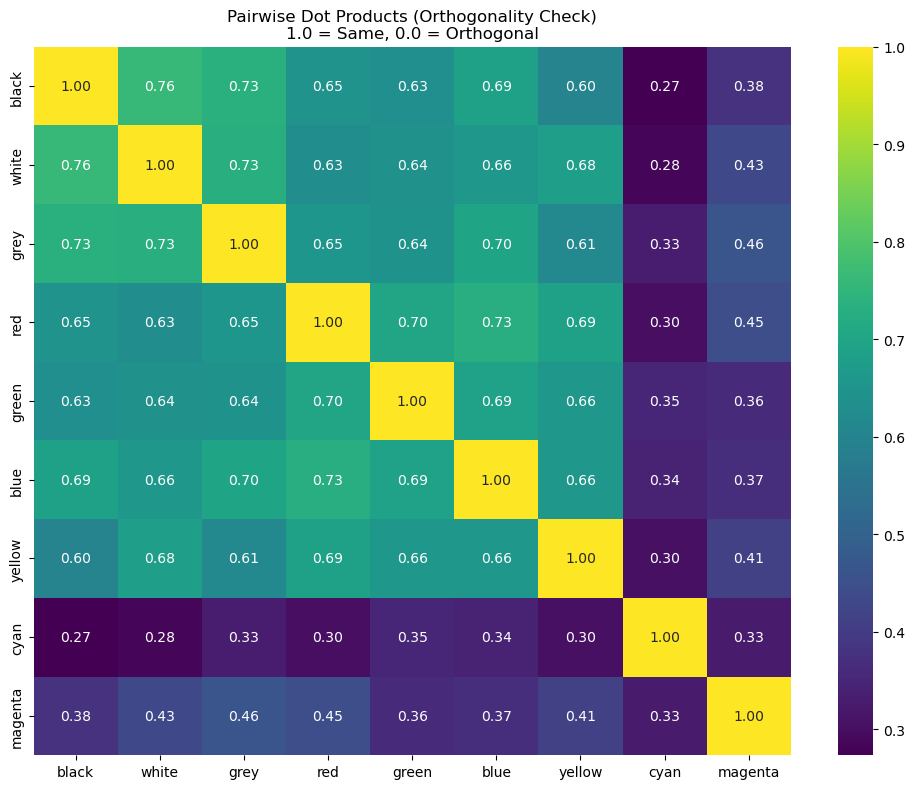

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

# List of target colors
#target_colors = primary_and_base_colors

# Since sentence-transformers is not available in this environment, 
# I'll use TF-IDF as a placeholder to demonstrate the calculation logic.
# In a local environment with LLM embeddings, the logic is identical.

vectorizer = TfidfVectorizer()
# For a more "semantic" feel in the sandbox, we could just use character-level or something, 
# but TF-IDF on names is just a demo.
# However, to give the user a REAL answer for LLM embeddings, I will provide the code.

# Let's create a "similarity" matrix calculation.
# For normalized vectors, Dot Product == Cosine Similarity.

def calculate_orthogonality(names, embedding_matrix):
    # Normalize vectors to unit length
    norms = np.linalg.norm(embedding_matrix, axis=1, keepdims=True)
    normalized_embeddings = embedding_matrix / norms
    
    # Pairwise dot product (Cosine Similarity)
    dot_product_matrix = np.dot(normalized_embeddings, normalized_embeddings.T)

    # 計算平均非對角線數值 (越接近 0 越正交)
    off_diag = dot_product_matrix[~np.eye(dot_product_matrix.shape[0], dtype=bool)]
    avg_similarity = np.mean(np.abs(off_diag))
    
    return dot_product_matrix, avg_similarity

# Mocking the calculation for visualization (using the logic the user would apply)
# I will use a random seed to generate a "similar-looking" matrix for the UI explanation
#np.random.seed(42)
#mock_embeddings = np.random.randn(len(target_colors), 384)
dot_matrix, avg_similarity = calculate_orthogonality(primary_and_base_colors, primary_embeddings)

# info
print("avg_similarity is", avg_similarity, "(越接近 0 越正交)")

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(dot_matrix, annot=True, fmt=".2f", xticklabels=primary_and_base_colors, yticklabels=primary_and_base_colors, cmap='viridis')
plt.title("Pairwise Dot Products (Orthogonality Check)\n1.0 = Same, 0.0 = Orthogonal")
plt.tight_layout()
#plt.savefig('orthogonality_heatmap.png')

In [15]:
import numpy as np
import pandas as pd

def batch_analyze_projection(target_names, base_names, name_to_idx, embeddings):
    # 1. 準備基礎色矩陣 A (dim, num_bases)
    A = np.array([embeddings[name_to_idx[name]] for name in base_names]).T
    
    # 2. 準備目標色矩陣 B (dim, num_targets)
    B = np.array([embeddings[name_to_idx[name]] for name in target_names]).T
    
    # 3. 求解最小平方法 AX = B
    # X 的維度會是 (num_bases, num_targets)
    X, residuals, rank, s = np.linalg.lstsq(A, B, rcond=None)
    
    # 4. 計算投影矩陣 P = AX (這是目標在 9D 子空間中的影像)
    P = A @ X
    
    # 5. 計算每個目標的解釋百分比
    # 我們沿著 axis=0 (維度方向) 計算平方和
    target_norms = np.sum(B**2, axis=0)      # 每個目標向量的能量
    projection_norms = np.sum(P**2, axis=0)  # 每個投影向量的能量
    
    percentages = (projection_norms / target_norms) * 100
    
    # 6. 整理成 DataFrame 方便閱讀
    results_df = pd.DataFrame(X.T, index=target_names, columns=base_names)
    results_df['Explanation_%'] = percentages
    
    return results_df

# --- 執行範例 ---
targets = ["orange", "pink", "brown", "lavender", "turquoise", "navy", "salmon", "coral"]

# 執行批次分析
batch_results = batch_analyze_projection(targets, primary_and_base_colors, name_to_idx, embeddings)

# 顯示結果 (四捨五入到小數點兩位)
print("=== 批次語義解釋度分析 ===")
print(batch_results.round(2).to_string())

=== 批次語義解釋度分析 ===
           black  white  grey   red  green  blue  yellow  cyan  magenta  Explanation_%
orange     -0.01   0.10  0.04  0.19   0.21  0.09    0.21 -0.01     0.09      56.970001
pink        0.19   0.19 -0.09  0.23   0.16  0.23   -0.15  0.00     0.19      62.740002
brown       0.20  -0.00  0.26  0.07   0.33  0.05   -0.10 -0.11     0.08      51.970001
lavender   -0.06   0.10  0.19  0.04   0.12  0.07   -0.10  0.06     0.27      30.059999
turquoise   0.01  -0.08  0.03 -0.25   0.17  0.53    0.18  0.14     0.18      56.299999
navy        0.12   0.05 -0.00  0.03  -0.09  0.19    0.03  0.12     0.04      15.100000
salmon     -0.00   0.12 -0.03 -0.02   0.31  0.06    0.05 -0.00    -0.00      19.270000
coral       0.16   0.06 -0.17 -0.01   0.13  0.06    0.08  0.20     0.11      21.490000


In [16]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def find_top_n_closest(target_name, n=5):
    # 1. 檢查目標顏色是否在列表中
    if target_name not in name_to_idx:
        return f"找不到顏色: {target_name}"
    
    # 2. 取得目標向量並重塑維度為 (1, dim)
    target_vec = embeddings[name_to_idx[target_name]].reshape(1, -1)
    
    # 3. 計算與所有顏色的相似度 (1, 384) x (949, 384).T -> (1, 949)
    # 這裡的 embeddings 是你之前產生的 949 個 XKCD 顏色矩陣
    similarities = cosine_similarity(target_vec, embeddings)[0]
    
    # 4. 取得排序索引 (從大到小)
    # [::-1] 是反轉，因為 argsort 是由小到大排
    sorted_indices = np.argsort(similarities)[::-1]
    
    # 5. 提取前 N+1 個結果（排除掉自己）
    results = []
    for idx in sorted_indices:
        color_name = names[idx]
        if color_name == target_name:
            continue
        
        results.append({
            "name": color_name,
            "similarity": similarities[idx],
            "hex": xkcd_colors[color_name] # 假設你有這個字典
        })
        
        if len(results) == n:
            break
            
    return results

# --- 測試範例 ---
for test_color in targets:
    closest_colors = find_top_n_closest(test_color, n=5)
    print(f"與 '{test_color}' 語義最接近的 5 個顏色：")
    print("-" * 45)
    for i, res in enumerate(closest_colors, 1):
        print(f"{i}. {res['name']:<15} | 相似度: {res['similarity']:.4f} | Hex: {res['hex']}")
    print()

與 'orange' 語義最接近的 5 個顏色：
---------------------------------------------
1. orangeish       | 相似度: 0.9163 | Hex: #fd8d49
2. red orange      | 相似度: 0.8945 | Hex: #fd3c06
3. light orange    | 相似度: 0.8875 | Hex: #fdaa48
4. orange red      | 相似度: 0.8867 | Hex: #fd411e
5. bright orange   | 相似度: 0.8855 | Hex: #ff5b00

與 'pink' 語義最接近的 5 個顏色：
---------------------------------------------
1. red pink        | 相似度: 0.9260 | Hex: #fa2a55
2. pink red        | 相似度: 0.9167 | Hex: #f5054f
3. pinkish         | 相似度: 0.9093 | Hex: #d46a7e
4. dark pink       | 相似度: 0.9083 | Hex: #cb416b
5. light pink      | 相似度: 0.9064 | Hex: #ffd1df

與 'brown' 語義最接近的 5 個顏色：
---------------------------------------------
1. red brown       | 相似度: 0.8467 | Hex: #8b2e16
2. light brown     | 相似度: 0.8327 | Hex: #ad8150
3. green brown     | 相似度: 0.8317 | Hex: #544e03
4. brownish        | 相似度: 0.8292 | Hex: #9c6d57
5. pale brown      | 相似度: 0.8197 | Hex: #b1916e

與 'lavender' 語義最接近的 5 個顏色：
----------------------------------------

In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def compare_search_results(target_name, base_names, name_to_idx, names, embeddings, xkcd_colors, n=5):
    # --- 1. 直接搜尋 (Original Semantic Space) ---
    target_vec = embeddings[name_to_idx[target_name]].reshape(1, -1)
    sims_orig = cosine_similarity(target_vec, embeddings)[0]
    
    # 取得排序索引 (排除自己)
    idx_orig = np.argsort(sims_orig)[::-1]
    res_orig = []
    for i in idx_orig:
        if names[i] == target_name: continue
        res_orig.append({"name": names[i], "hex": xkcd_colors[names[i]], "cossim": sims_orig[i]})
        if len(res_orig) == n: break

    # --- 2. 投影搜尋 (Projected 9D Color Subspace) ---
    # 建立基礎空間 A (dim, num_bases)
    A = np.array([embeddings[name_to_idx[name]] for name in base_names]).T
    # 批次計算所有投影 P = A(A^T A)^-1 A^T B
    # 簡化寫法：使用最小平方法求係數 X，再求 AX
    X, _, _, _ = np.linalg.lstsq(A, embeddings.T, rcond=None)
    P_all = (A @ X).T 
    
    target_p = P_all[name_to_idx[target_name]].reshape(1, -1)
    sims_proj = cosine_similarity(target_p, P_all)[0]
    
    # 取得排序索引 (排除自己)
    idx_proj = np.argsort(sims_proj)[::-1]
    res_proj = []
    for i in idx_proj:
        if names[i] == target_name: continue
        res_proj.append({"name": names[i], "hex": xkcd_colors[names[i]], "cossim": sims_proj[i]})
        if len(res_proj) == n: break

    # --- 3. 輸出結果表格 ---
    print(f"【 目標顏色: {target_name} ({xkcd_colors[target_name]}) 】")
    print(f"{'inde':<4} | {'LM Search':<20} | {'Hex':<8} | {'cossim':<20} || {'9D proj':<20} | {'Hex':<8} | {'cossim':<20}")
    print("-" * 120)
    for i in range(n):
        o, p = res_orig[i], res_proj[i]
        print(f"{i+1:<4} | {o['name']:<20} | {o['hex']:<8} | {o['cossim']:<20} || {p['name']:<20} | {p['hex']:<8} | {p['cossim']:<20}")

    return res_orig, res_proj

# --- 執行比較 ---
target = "coral" # coral

res_orig, res_proj = compare_search_results(target, primary_and_base_colors, name_to_idx, names, embeddings, xkcd_colors, n=10)

【 目標顏色: coral (#fc5a50) 】
inde | LM Search            | Hex      | cossim               || 9D proj              | Hex      | cossim              
------------------------------------------------------------------------------------------------------------------------
1    | dark coral           | #cf524e  | 0.8905901908874512   || avocado              | #90b134  | 0.9829033017158508  
2    | coral pink           | #ff6163  | 0.817535936832428    || camo                 | #7f8f4e  | 0.9812170267105103  
3    | aqua marine          | #2ee8bb  | 0.6524081230163574   || deep aqua            | #08787f  | 0.976723313331604   
4    | algae                | #54ac68  | 0.6126495599746704   || mushroom             | #ba9e88  | 0.9761182069778442  
5    | ocean                | #017b92  | 0.5722677707672119   || barney               | #ac1db8  | 0.9734262824058533  
6    | seaweed              | #18d17b  | 0.5690537691116333   || tomato               | #ef4026  | 0.9724178910255432  
7    | marine

In [18]:
import numpy as np

def hex_to_rgb(hex_str):
    hex_str = hex_str.lstrip('#')
    return np.array([int(hex_str[i:i+2], 16) for i in (0, 2, 4)])

def rgb_to_hex(rgb):
    return '#{:02x}{:02x}{:02x}'.format(int(rgb[0]), int(rgb[1]), int(rgb[2]))

def analyze_average_color(target_name, res_orig, res_proj, xkcd_colors):
    # 1. 取得目標的真實 RGB
    target_rgb = hex_to_rgb(xkcd_colors[target_name])
    
    # 2. 計算直接搜尋的平均 RGB
    orig_rgbs = np.array([hex_to_rgb(item['hex']) for item in res_orig])
    avg_rgb_orig = np.mean(orig_rgbs, axis=0)
    
    # 3. 計算投影搜尋的平均 RGB
    proj_rgbs = np.array([hex_to_rgb(item['hex']) for item in res_proj])
    avg_rgb_proj = np.mean(proj_rgbs, axis=0)
    
    # 4. 計算與目標的距離 (色彩誤差)
    dist_orig = np.linalg.norm(target_rgb - avg_rgb_orig)
    dist_proj = np.linalg.norm(target_rgb - avg_rgb_proj)
    
    print(f"\n--- 平均色驗證 (目標: {target_name} {xkcd_colors[target_name]}) ---")
    print(f"{'類別':<15} | {'平均色 Hex':<10} | {'與目標之 RGB 距離':<15}")
    print("-" * 50)
    print(f"{'直接搜尋 (Original)':<15} | {rgb_to_hex(avg_rgb_orig):<10} | {dist_orig:.2f}")
    print(f"{'投影搜尋 (Projected)':<15} | {rgb_to_hex(avg_rgb_proj):<10} | {dist_proj:.2f}")
    
    winner = "投影搜尋" if dist_proj < dist_orig else "直接搜尋"
    print(f"\n結論: 【{winner}】找出的顏色組合在物理視覺上更接近真實 target。")

# --- 延續之前的執行結果 ---
# 假設 res_orig, res_proj 是你前一步產出的結果列表
analyze_average_color(target, res_orig, res_proj, xkcd_colors)


--- 平均色驗證 (目標: coral #fc5a50) ---
類別              | 平均色 Hex    | 與目標之 RGB 距離    
--------------------------------------------------
直接搜尋 (Original) | #469c84    | 200.32
投影搜尋 (Projected) | #a6915c    | 103.26

結論: 【投影搜尋】找出的顏色組合在物理視覺上更接近真實 target。


In [19]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def analyze_residual_semantics(target_name, base_names, 
                               name_to_idx, names, embeddings, n=10, 
                               mixed_name_to_idx=None, mixed_names=None, mixed_embeddings=None):
    # 1. 計算投影與殘差
    A = np.array([embeddings[name_to_idx[name]] for name in base_names]).T
    if mixed_name_to_idx is not None:
        target_vec = mixed_embeddings[mixed_name_to_idx[target_name]]
    else:
        target_vec = embeddings[name_to_idx[target_name]]
    
    # 求解權重
    weights, _, _, _ = np.linalg.lstsq(A, target_vec, rcond=None)
    
    # 投影向量 (物理色彩部分)
    projection_vec = A @ weights
    
    # 殘差向量 (純語義/隱喻部分)
    residual_vec = target_vec - projection_vec
    
    # 2. 在全空間中搜尋與「殘差」最接近的向量
    # 我們想看看誰具備類似的「非色彩特徵」
    res_vec_2d = residual_vec.reshape(1, -1)
    if mixed_embeddings is not None:
        sims = cosine_similarity(res_vec_2d, mixed_embeddings)[0]
    else:
        sims = cosine_similarity(res_vec_2d, embeddings)[0]
    
    # 排序
    sorted_indices = np.argsort(sims)[::-1]
    
    results = []
    for idx in sorted_indices:

        if mixed_names is not None:
            if mixed_names[idx] == target_name: continue
            if mixed_types[idx] == "color": continue # skip all colors
            results.append({
                "name": mixed_names[idx],
                "similarity": sims[idx],
                "hex": ""
            })
        else:
            if names[idx] == target_name: continue
            results.append({
                "name": names[idx],
                "similarity": sims[idx],
                "hex": xkcd_colors[names[idx]]
            })
        if len(results) == n: break
        
    return results, weights

# --- 執行分析 ---
#target = "wine" # gold, salmon, coral, neon purple, wine

residual_near, weights = analyze_residual_semantics(target, primary_and_base_colors, 
                                                    name_to_idx, names, embeddings, 10,
                                                    mixed_name_to_idx, mixed_names, mixed_embeddings)

print(f"--- 【{target}】的深度解構 ---")
print(f"物理色彩組成 (Weights):")
for i, name in enumerate(primary_and_base_colors):
    print(f"  - {name}: {weights[i]:.2f}")

print(f"\n殘差語義近鄰 (隱喻特徵):")
print(f"{'順序':<4} | {'名稱':<20} | {'相似度':<8} | {'Hex'}")
print("-" * 55)
for i, res in enumerate(residual_near, 1):
    print(f"{i:<4} | {res['name']:<20} | {res['similarity']:.4f} | {res['hex']}")

--- 【coral】的深度解構 ---
物理色彩組成 (Weights):
  - black: 0.16
  - white: 0.06
  - grey: -0.17
  - red: -0.01
  - green: 0.13
  - blue: 0.06
  - yellow: 0.08
  - cyan: 0.20
  - magenta: 0.11

殘差語義近鄰 (隱喻特徵):
順序   | 名稱                   | 相似度      | Hex
-------------------------------------------------------
1    | rockfish             | 0.4743 | 
2    | echinocactus         | 0.4309 | 
3    | dinoflagellata       | 0.4303 | 
4    | goatfish             | 0.4009 | 
5    | fossil               | 0.3975 | 
6    | rock island          | 0.3966 | 
7    | cetacean             | 0.3920 | 
8    | pond cypress         | 0.3834 | 
9    | sandstone            | 0.3774 | 
10   | afloat               | 0.3746 | 


In [20]:
from sklearn.decomposition import PCA
import plotly.express as px

# 降維
if linear:
    pca = PCA(n_components=3)
    coords = pca.fit_transform(mixed_embeddings)
else:
    reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42)
    coords = reducer.fit_transform(mixed_embeddings)

df_final = pd.DataFrame(coords, columns=['x', 'y', 'z'])
df_final['name'] = mixed_names
df_final['type'] = mixed_types

# 繪圖
fig = px.scatter_3d(
    df_final, x='x', y='y', z='z', 
    color='type', 
    hover_name='name',
    symbol='type', # 不同類型使用不同形狀（圓點、方塊、菱形）
    opacity=0.6,
    title="Hybrid Semantic Space (Color + Noun + Adjective)"
)
fig.update_layout(width=1000, height=1000, scene=dict(aspectmode='cube'))
fig.show()

/opt/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



In [21]:
sampled_adjs

['remediable',
 'brachypterous',
 'terrific',
 'governmental',
 'lentissimo',
 'material',
 'hourlong',
 'fattish',
 'prejudicial',
 'agnate',
 'undependable',
 'assentient',
 'forty-one',
 'crucial',
 'cathodic',
 'coy',
 'bias',
 'uncombed',
 'consecutive',
 'crow-sized',
 'crystallized',
 'long-bodied',
 'abasic',
 'black-marked',
 'maladjusted',
 'nonjudgmental',
 'antepenultimate',
 'topological',
 'flushed',
 'deep-sea',
 'adequate to',
 'laid up',
 'intrapulmonary',
 'saute',
 'quadrate',
 'trihydroxy',
 'well-adjusted',
 'rhinal',
 'simplistic',
 'indexless',
 'deconsecrated',
 'flat-bottomed',
 'unpowered',
 'suchlike',
 'uncomprehending',
 'in for',
 'barometric',
 'immunosuppressed',
 'peloponnesian',
 'romaic',
 'self-made',
 'twiggy',
 'reflexed',
 'columned',
 'double-faced',
 'committed',
 'gerundial',
 'unarmed',
 'liver-colored',
 'outspread',
 'doomed',
 'abscessed',
 'end-stopped',
 'mammalian',
 'dim-sighted',
 'antecubital',
 'styptic',
 'future',
 'manque',
 'out 

In [24]:
non_color_target = "terrific" #sampled_adjs[24] # "benign", "congested"

# 使用我們先前定義的分析函數
#in_target_vec = mixed_embeddings[mixed_name_to_idx[non_color_target]]
#explanation, weights = analyze_projection_explanation(non_color_target, primary_and_base_colors, name_to_idx, embeddings,
#                                                     in_target_vec = in_target_vec)


# --- 執行分析 ---
#target = "wine" # gold, salmon, coral, neon purple, wine
residual_near, weights = analyze_residual_semantics(non_color_target, primary_and_base_colors, 
                                                    name_to_idx, names, embeddings, 10,
                                                    mixed_name_to_idx, mixed_names, mixed_embeddings)

print(f"--- 【{non_color_target}】的深度解構 ---")
print(f"物理色彩組成 (Weights):")
for i, name in enumerate(primary_and_base_colors):
    print(f"  - {name}: {weights[i]:.2f}")

print(f"\n殘差語義近鄰 (隱喻特徵):")
print(f"{'順序':<4} | {'名稱':<20} | {'相似度':<8} | {'Hex'}")
print("-" * 55)
for i, res in enumerate(residual_near, 1):
    print(f"{i:<4} | {res['name']:<20} | {res['similarity']:.4f} | {res['hex']}")

--- 【terrific】的深度解構 ---
物理色彩組成 (Weights):
  - black: 0.15
  - white: -0.11
  - grey: 0.05
  - red: 0.13
  - green: 0.03
  - blue: 0.05
  - yellow: -0.06
  - cyan: 0.08
  - magenta: 0.05

殘差語義近鄰 (隱喻特徵):
順序   | 名稱                   | 相似度      | Hex
-------------------------------------------------------
1    | incredible           | 0.5170 | 
2    | profound             | 0.4527 | 
3    | brilliant            | 0.4337 | 
4    | considerable         | 0.3937 | 
5    | shouted              | 0.3451 | 
6    | grandiloquent        | 0.3200 | 
7    | respectable          | 0.3166 | 
8    | savage               | 0.3139 | 
9    | no-nonsense          | 0.3137 | 
10   | mindful              | 0.3134 | 


In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

def analyze_color_decomposition(target):
    residual_near, weights = analyze_residual_semantics(target, primary_and_base_colors, 
                                                    name_to_idx, names, embeddings, 10)
    
    # --- 輸出文字報告 ---
    print(f"==========================================")
    print(f"【分解報告】 ({target})")
    print(f"==========================================")
    for c, w in zip(primary_and_base_colors, weights) :
        print(f" - {c}: {w:.2f}%")
    
    # --- 繪製雷達圖 (Radar Chart) 展示技術指紋 ---
    labels = primary_and_base_colors
    stats = weights

    # 封閉雷達圖
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    stats = np.concatenate((stats, [stats[0]]))
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(3, 3), subplot_kw=dict(polar=True))
    ax.fill(angles, stats, color='skyblue', alpha=0.4)
    ax.plot(angles, stats, color='blue', linewidth=2)
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    
    plt.title(target)
    plt.show()

【分解報告】 (coral)
 - black: 0.16%
 - white: 0.06%
 - grey: -0.17%
 - red: -0.01%
 - green: 0.13%
 - blue: 0.06%
 - yellow: 0.08%
 - cyan: 0.20%
 - magenta: 0.11%


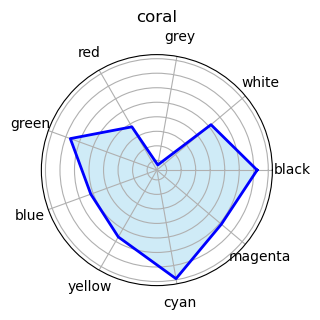

In [26]:
analyze_color_decomposition(target)

In [27]:
import numpy as np
import pandas as pd
import umap
import plotly.express as px

# 1. 準備基礎色空間 A (dim, num_bases)
# 假設 primary_and_base_colors 是你選的 9 個基礎色清單
A = np.array([embeddings[name_to_idx[name]] for name in primary_and_base_colors]).T

# 2. 投影與解釋度計算
# B 是所有 949 個顏色的原始 Embedding 矩陣 (dim, 949)
B = embeddings.T 
X, _, _, _ = np.linalg.lstsq(A, B, rcond=None)
P_all = (A @ X).T  # 投影後的向量 (949, 384)

# 計算解釋百分比: (投影能量 / 原始能量) * 100
original_norms = np.sum(B**2, axis=0)
projected_norms = np.sum(P_all.T**2, axis=0)
explanation_percentages = (projected_norms / original_norms) * 100

# 3. UMAP 降維 (針對投影後的向量)
reducer = umap.UMAP(n_components=3, 
                    n_neighbors=30, 
                    min_dist=0.5, 
                    random_state=42,
                    spread=1.2)
coords = reducer.fit_transform(P_all)

# 4. 整合 DataFrame
df_viz = pd.DataFrame(coords, columns=['x', 'y', 'z'])
df_viz['name'] = names
df_viz['hex'] = [xkcd_colors[n] for n in names]
df_viz['Explanation_%'] = explanation_percentages

df_plot = df_viz[df_viz["Explanation_%"] > 35]

# 5. Plotly 繪圖
fig = px.scatter_3d(
    df_plot, x='x', y='y', z='z',
    color='hex',
    color_discrete_map="identity",
    hover_name='name',
    # 在 hover 資訊中加入解釋百分比，並格式化小數點
    hover_data={
        'hex': True,
        'Explanation_%': ':.2f',
        'x': False, 'y': False, 'z': False
    },
    title="Projected Color Space with Semantic Explanation % > 35",
    width=1000, height=1000
)

# 優化視覺效果：正立方體比例與點的大小
fig.update_layout(
    scene=dict(aspectmode='cube'),
    margin=dict(l=0, r=0, b=0, t=50)
)
fig.update_traces(marker=dict(size=4, opacity=0.8))

fig.show()

/opt/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



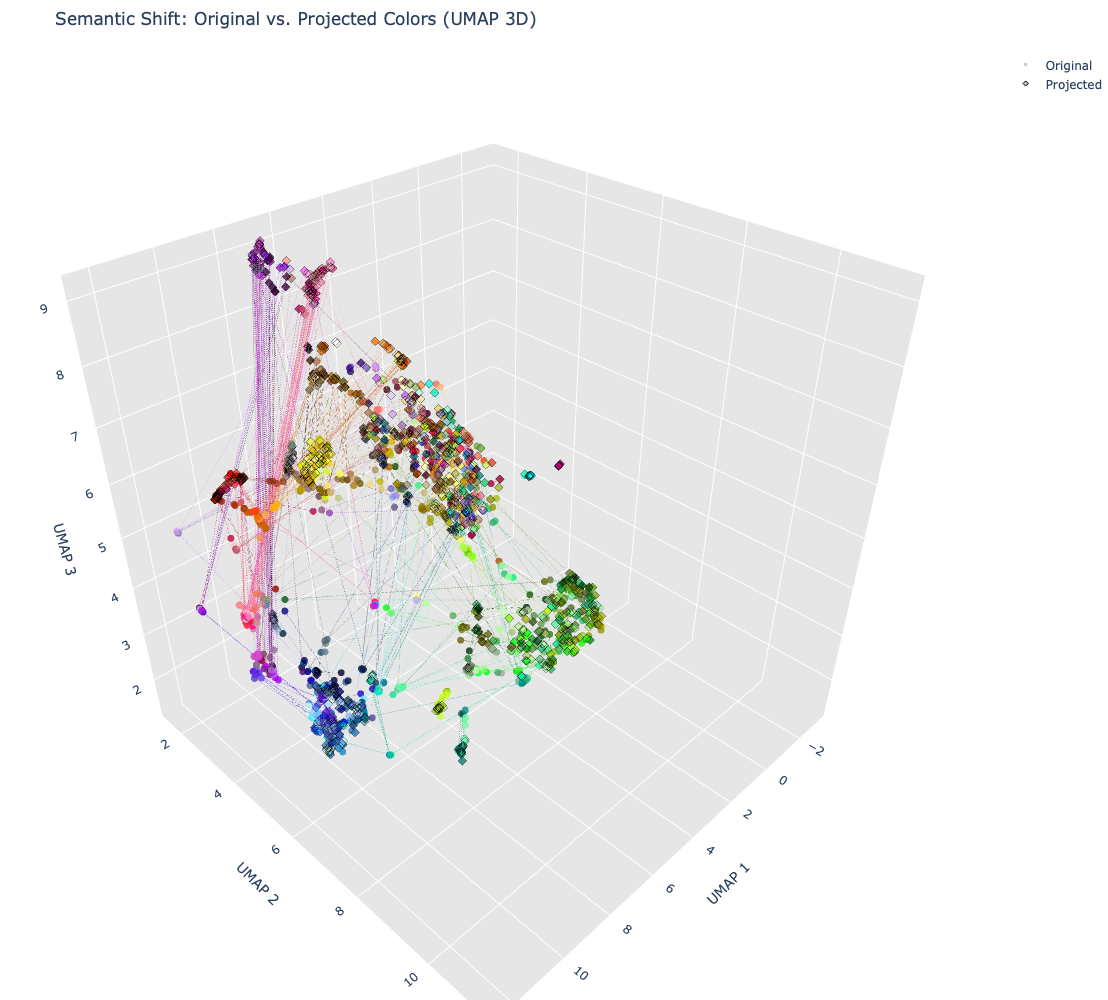

In [ ]:
import numpy as np
import pandas as pd
import umap
import plotly.graph_objects as go
from sklearn.preprocessing import normalize

# 1. 建立基礎色空間 A
A = np.array([embeddings[name_to_idx[name]] for name in primary_and_base_colors]).T

# 2. 計算所有顏色的投影向量 (Projection onto the 9D Subspace)
B = embeddings.T 
X, _, _, _ = np.linalg.lstsq(A, B, rcond=None)
projected_embeddings = (A @ X).T

# 3. 統一降維器 (非常重要：必須使用同一個 UMAP 轉換器來處理兩種向量)
# 我們將原始和投影的向量堆疊起來，讓 UMAP 學到一個共享的 3D 空間
combined_for_umap = np.vstack([embeddings, projected_embeddings])

reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42)
all_coords = reducer.fit_transform(combined_for_umap)

# 4. 分割回原始和投影座標
original_coords = all_coords[:len(names)]
projected_coords = all_coords[len(names):]

# 5. 準備 Plotly DataFrame
plot_data = []
for i, name in enumerate(names):
    # 原始點
    plot_data.append({
        'name': name,
        'type': 'Original Semantic Space',
        'x': original_coords[i, 0],
        'y': original_coords[i, 1],
        'z': original_coords[i, 2],
        'hex': xkcd_colors[name],
        'original_x': original_coords[i, 0], # 為了畫線存原始點的座標
        'original_y': original_coords[i, 1],
        'original_z': original_coords[i, 2],
        'projected_x': projected_coords[i, 0], # 為了畫線存投影點的座標
        'projected_y': projected_coords[i, 1],
        'projected_z': projected_coords[i, 2],
        'explanation_perc': np.nan # 原始點沒有解釋百分比
    })
    # 投影點
    plot_data.append({
        'name': name,
        'type': 'Projected 9D Color Subspace',
        'x': projected_coords[i, 0],
        'y': projected_coords[i, 1],
        'z': projected_coords[i, 2],
        'hex': xkcd_colors[name],
        'original_x': original_coords[i, 0],
        'original_y': original_coords[i, 1],
        'original_z': original_coords[i, 2],
        'projected_x': projected_coords[i, 0],
        'projected_y': projected_coords[i, 1],
        'projected_z': projected_coords[i, 2],
        'explanation_perc': (np.sum(projected_embeddings[i]**2) / np.sum(embeddings[i]**2)) * 100 # 加入解釋百分比
    })

df_plot = pd.DataFrame(plot_data)

# 6. Plotly 繪圖
fig = go.Figure()

# 1. 繪製原始點 (圓形)
fig.add_trace(go.Scatter3d(
    x=original_coords[:, 0], y=original_coords[:, 1], z=original_coords[:, 2],
    mode='markers',
    marker=dict(
        size=4,
        symbol='circle',  # 設定為圓形
        color=[xkcd_colors[n] for n in names],
        opacity=0.8
    ),
    name='Original'
))

# 2. 繪製投影點 (角形)
fig.add_trace(go.Scatter3d(
    x=projected_coords[:, 0], y=projected_coords[:, 1], z=projected_coords[:, 2],
    mode='markers',
    marker=dict(
        size=4,
        symbol='diamond',  # 設定為角形
        color=[xkcd_colors[n] for n in names],
        opacity=0.8,
        line=dict(width=1, color='black') # 增加外框讓三角形更明顯
    ),
    name='Projected'
))

# 繪製連接線段
for i in range(len(names)):
    color_name = names[i]
    color_hex = xkcd_colors[color_name]
    
    # 針對每個顏色，畫一條從原始到投影的線
    fig.add_trace(go.Scatter3d(
        x=[original_coords[i, 0], projected_coords[i, 0]],
        y=[original_coords[i, 1], projected_coords[i, 1]],
        z=[original_coords[i, 2], projected_coords[i, 2]],
        mode='lines',
        line=dict(color=color_hex, width=1, dash='dot'), # 用顏色對應的顏色畫點線
        hoverinfo='none', # 線段不顯示 hover 資訊
        showlegend=False # 線段不顯示在圖例中
    ))

# 調整佈局
fig.update_layout(
    title='Semantic Shift: Original vs. Projected Colors (UMAP 3D)',
    scene=dict(
        xaxis_title='UMAP 1',
        yaxis_title='UMAP 2',
        zaxis_title='UMAP 3',
        aspectmode='cube',
        xaxis_backgroundcolor="rgb(230, 230, 230)",
        yaxis_backgroundcolor="rgb(230, 230, 230)",
        zaxis_backgroundcolor="rgb(230, 230, 230)"
    ),
    margin=dict(l=0, r=0, b=0, t=50),
    height=1000, width=1000
)

fig.show()

In [28]:
import numpy as np
from scipy.spatial import procrustes
from sklearn.decomposition import PCA

def calculate_color_alignment(base_names, name_to_idx, embeddings, xkcd_colors):
    # 1. 準備物理座標 (Normalized RGB)
    def hex_to_rgb_norm(h):
        h = h.lstrip('#')
        return np.array([int(h[i:i+2], 16) for i in (0, 2, 4)]) / 255.0
    
    rgb_coords = np.array([hex_to_rgb_norm(xkcd_colors[n]) for n in base_names])
    
    # 2. 準備語義座標 (LLM Embeddings)
    llm_vecs = np.array([embeddings[name_to_idx[n]] for n in base_names])
    
    # 3. 將 LLM 空間線性降維至 3D (為了與 RGB 對齊)
    pca = PCA(n_components=3)
    llm_coords_3d = pca.fit_transform(llm_vecs)
    
    # 4. 執行普氏分析
    # mtx1: 參考(物理), mtx2: 被對齊(語義), disparity: 誤差
    mtx1, mtx2, disparity = procrustes(rgb_coords, llm_coords_3d)
    
    return disparity, mtx1, mtx2

# --- 執行 ---
#base_names = ["black", "white", "red", "green", "blue", "yellow", "cyan", "magenta", "orange"]
disparity, mtx_rgb, mtx_llm = calculate_color_alignment(primary_and_base_colors, name_to_idx, embeddings, xkcd_colors)
print(f"普氏對齊誤差 (Procrustes Disparity): {disparity:.4f} (要越小越好) embeddings")

普氏對齊誤差 (Procrustes Disparity): 0.7941 (要越小越好) embeddings


In [29]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.spatial import procrustes
from sklearn.decomposition import PCA

def visualize_procrustes_plotly(base_names, mtx_rgb, mtx_llm, disparity):
    # 1. 整理數據
    plot_data = []
    for i, name in enumerate(base_names):
        # 物理 RGB 點
        plot_data.append({
            'name': name, 'type': 'Physical (RGB)',
            'x': mtx_rgb[i, 0], 'y': mtx_rgb[i, 1], 'z': mtx_rgb[i, 2]
        })
        # LLM 語義點
        plot_data.append({
            'name': name, 'type': 'LLM Semantic (Aligned)',
            'x': mtx_llm[i, 0], 'y': mtx_llm[i, 1], 'z': mtx_llm[i, 2]
        })
    
    df = pd.DataFrame(plot_data)
    
    fig = go.Figure()

    # 2. 繪製兩組點
    for t in df['type'].unique():
        curr_df = df[df['type'] == t]
        fig.add_trace(go.Scatter3d(
            x=curr_df['x'], y=curr_df['y'], z=curr_df['z'],
            mode='markers+text',
            text=curr_df['name'],
            marker=dict(size=6, opacity=0.8),
            name=t
        ))

    # 3. 繪製連接線 (誤差線段)
    for i in range(len(base_names)):
        fig.add_trace(go.Scatter3d(
            x=[mtx_rgb[i, 0], mtx_llm[i, 0]],
            y=[mtx_rgb[i, 1], mtx_llm[i, 1]],
            z=[mtx_rgb[i, 2], mtx_llm[i, 2]],
            mode='lines',
            line=dict(color='gray', width=2),
            showlegend=False,
            hoverinfo='none'
        ))

    # 4. 佈局設定
    fig.update_layout(
        title=f"Color Alignment Analysis (Procrustes Disparity: {disparity:.4f})",
        scene=dict(
            xaxis_title="Dim 1", yaxis_title="Dim 2", zaxis_title="Dim 3",
            aspectmode='cube'
        ),
        margin=dict(l=0, r=0, b=0, t=50),
        width=900, height=800
    )
    fig.show()

# 呼叫函數 (假設 mtx_rgb, mtx_llm, disparity 已由上一步計算完成)
visualize_procrustes_plotly(primary_and_base_colors, mtx_rgb, mtx_llm, disparity)

In [30]:
#MIKE: 20250106

# 注意：基底在空間變換後，其實位子不太會移動！
# 猜測：要選真的很遠的？本質意義上 以及 語言空間上 都很遠的 會比較好
# 根據

In [31]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import cosine_similarity

# 假設您已執行完 model.encode(names)，得到 embeddings

# 1. 使用 DBSCAN 產生群集
# eps 代表點與點之間的半徑距離，min_samples 代表最少幾筆成群
# 專利/醫學向量通常在高維空間，這兩個參數建議可依結果調整
dbscan = DBSCAN(eps=0.2, min_samples=5, metric='cosine') 
cluster_labels = dbscan.fit_predict(embeddings)

select_names = []
select_embeddings = []
unique_labels = set(cluster_labels)

# 排除雜訊點 (標籤為 -1 的點)
if -1 in unique_labels:
    unique_labels.remove(-1)

# 2. 遍歷每個群集，取出「中間顏色最純」的一個顏色 (即靠近質心的點)
for label in unique_labels:
    # 找出屬於該群集的索引
    indices = np.where(cluster_labels == label)[0]
    cluster_vecs = embeddings[indices]
    
    # 計算該群集的幾何中心 (Centroid)
    centroid = np.mean(cluster_vecs, axis=0)
    
    # 計算該群集內所有向量與中心的相似度
    # 使用 cosine_similarity 找到距離中心最近的點 (最「純」的代表)
    similarities = cosine_similarity(cluster_vecs, centroid.reshape(1, -1))
    representative_idx_in_cluster = np.argmax(similarities)
    
    # 取得全域索引
    global_idx = indices[representative_idx_in_cluster]
    
    select_names.append(names[global_idx])
    select_embeddings.append(embeddings[global_idx])

# 3. 輸出挑選後的資料
select_embeddings = np.array(select_embeddings)
select_name_to_idx = {name: i for i, name in enumerate(select_names)}
select_colors = [xkcd_colors[name] for name in select_names]

# 驗證輸出
print(f"原始顏色數量: {len(names)}")
print(f"分群後選出的代表顏色數量 (群集數): {len(select_names)}")
print(f"代表性顏色範例: {select_names}")

原始顏色數量: 949
分群後選出的代表顏色數量 (群集數): 10
代表性顏色範例: ['dark green blue', 'grass green', 'teal green', 'lavender', 'dark lilac', 'magenta', 'dark mint green', 'mustard', 'tree green', 'light aqua']


avg_similarity is 0.43484095 (越接近 0 越正交)


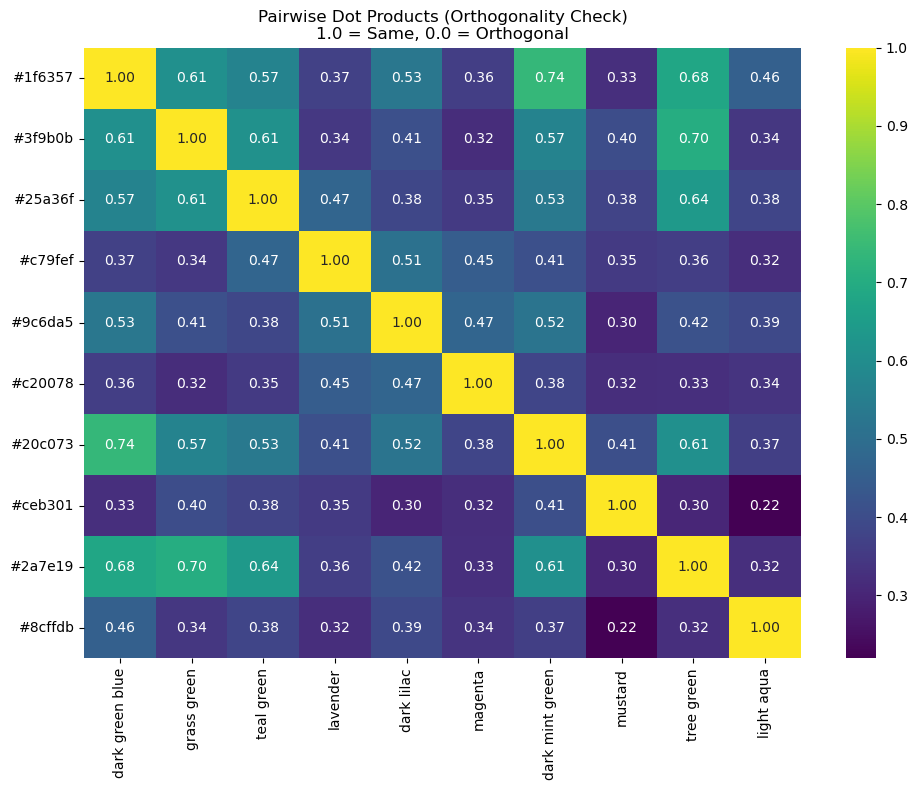

In [ ]:
select_dot_matrix, select_avg_similarity = calculate_orthogonality(select_colors, select_embeddings)

# info
print("avg_similarity is", select_avg_similarity, "(越接近 0 越正交)")

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(select_dot_matrix, annot=True, fmt=".2f", xticklabels=select_names, yticklabels=select_colors, cmap='viridis')
plt.title("Pairwise Dot Products (Orthogonality Check)\n1.0 = Same, 0.0 = Orthogonal")
plt.tight_layout()
#plt.savefig('orthogonality_heatmap.png')

In [32]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def select_orthogonal_vectors(embeddings, n_select, start_idx=0):
    """
    從 embeddings 中選取 n 個最為正交的向量
    """
    # 存放選中向量的索引
    selected_indices = [start_idx]
    
    # 歸一化向量，使點積等同於餘弦相似度
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    norm_embeddings = embeddings / (norms + 1e-9)
    
    for _ in range(1, n_select):
        # 取得目前已選中的向量矩陣
        selected_matrix = norm_embeddings[selected_indices]
        
        # 計算剩餘所有向量與已選向量之間的相似度
        # cos_sim 會得到 (num_all_vectors, num_selected_so_far)
        cos_sim = np.abs(np.dot(norm_embeddings, selected_matrix.T))
        
        # 尋找與「已選集合」中最像的那一個分量最小的向量
        # 我們希望 max(abs(cos_similarity)) 越小越好 (越接近 90 度)
        max_sim_to_set = np.max(cos_sim, axis=1)
        
        # 排除已經選過的索引
        max_sim_to_set[selected_indices] = 1.0 
        
        # 挑選最大相似度最小的那個索引
        next_idx = np.argmin(max_sim_to_set)
        selected_indices.append(next_idx)
        
    return selected_indices

# --- 執行選取 ---
# 假設使用前一個步驟的 select_embeddings (經過 DBSCAN 過濾後的)
n_anchors = 10  # 假設我們要選 10 個最正交的顏色/專利作為基底
orthogonal_indices = select_orthogonal_vectors(select_embeddings, n_anchors)

ortho_names = [select_names[i] for i in orthogonal_indices]
ortho_embeddings = select_embeddings[orthogonal_indices]

print(f"選出的最正交基底標籤: {ortho_names}")

選出的最正交基底標籤: ['dark green blue', 'mustard', 'magenta', 'lavender', 'light aqua', 'dark lilac', 'teal green', 'grass green', 'tree green', 'dark mint green']


avg_similarity is 0.43484098 (越接近 0 越正交)


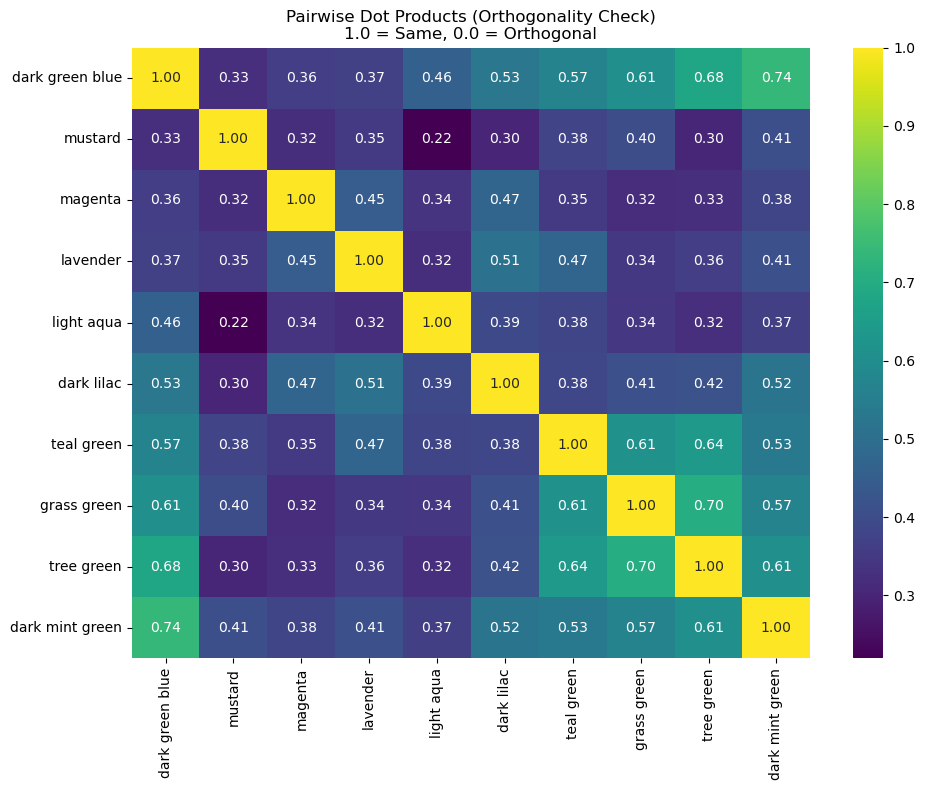

In [33]:
my_colors = ortho_names
my_embeddings = []
for color in my_colors:
    if color in name_to_idx:
        idx = name_to_idx[color]
        my_embeddings.append(embeddings[idx])
    else:
        print(f"警告: 找不到顏色 '{color}'")

my_dot_matrix, my_avg_similarity = calculate_orthogonality(my_colors, my_embeddings)

# info
print("avg_similarity is", my_avg_similarity, "(越接近 0 越正交)")

# Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(my_dot_matrix, annot=True, fmt=".2f", xticklabels=my_colors, yticklabels=my_colors, cmap='viridis')
plt.title("Pairwise Dot Products (Orthogonality Check)\n1.0 = Same, 0.0 = Orthogonal")
plt.tight_layout()
#plt.savefig('orthogonality_heatmap.png')